# Estimate VLM at global deltas

In [ ]:
from settings_and_functions import *

# Add some spatial information about Deltas

In [6]:
# DIVA LR model data containing InSAR estimates
ds_grouped=xr.open_dataset('_temp_/ds_grouped_1.nc') 

vals_ = ds_grouped.to_dataframe()

nic_ = pd.read_csv(settings['data_in']+'/MISC/Nicholls_deltas.csv',delimiter=';',encoding="ISO-8859-1")
eric_ = pd.read_csv(settings['data_in']+'/MISC/Ericson_table.csv',delimiter=';',encoding="ISO-8859-1")
coords_ = pd.read_csv(settings['data_in']+'/MISC/Delta_coords.csv',delimiter=';',encoding="ISO-8859-1",header=None).iloc[:,:3]


data = []
best = []

for Delta in eric_['Delta'][:]:
    if Delta.strip() == 'Bengal':
        Delta='Ganges/Brahmaputra'
    ex_ = process.extractOne(Delta, nic_['Delta'].values)
    data.append(nic_.loc[nic_['Delta']==ex_[0]])
    best.append(ex_[1])

data_c = pd.concat([eric_,pd.concat(data).reset_index()],axis=1)
data_c['prob '] = best
vals_ = np.asarray([float(str(val.replace(',',''))) for val in data_c['Delta Population (millions)']])
vals_[-1]=11.7
data_c['Delta Population (millions)'] = vals_

data_c_sorted = data_c.sort_values(by='Delta Population (millions)',ascending=False)

coords_.loc[:,1]= [float(val.replace('° N','').replace('° S','')) for val in coords_.loc[:,1]]
coords_.loc[:,2]= [float(val.replace('° E','').replace('° W','')) for val in coords_.loc[:,2]]

ds_deltas = xr.Dataset(
    data_vars=dict(
        delta=(["x"], [0]*len(coords_)),
        name=(["x"], coords_[0].values),
    ),
    coords=dict(
        lon=("x", coords_.loc[:,2]),
        lat=("x", coords_.loc[:,1]),
    ),
)

# Po Delta
ds_deltas['lat'][31]=44.9
ds_deltas['lon'][31]=12.30

# Get indices of ds_grouped over different length scales (75 - 600 km)

id_x400,d_x400 = sl(ds_grouped.x).couple(xr.concat([ds_deltas['delta'].x]*380,dim='x'),limit=400)
id_x600,d_x600 = sl(ds_grouped.x).couple(xr.concat([ds_deltas['delta'].x]*380,dim='x'),limit=600)
id_x,d_x = sl(ds_grouped.x).couple(xr.concat([ds_deltas['delta'].x]*380,dim='x'),limit=200)
id_x75,d_x75 = sl(ds_grouped.x).couple(xr.concat([ds_deltas['delta'].x]*380,dim='x'),limit=75)
ds_grouped['delta_id_400'] = d_x400.data
ds_grouped['delta_id_200'] = id_x.data
ds_grouped['delta_id_600'] = d_x600.data
ds_grouped['delta_id_75'] = d_x75.data

swap
nearest
x
400
swap
nearest
x
600
swap
nearest
x
200
swap
nearest
x
75


# Add global deltas from Ohenhen et al., 2026

In [7]:
# DIVA HR data

Ohenhen25_delta = xr.open_dataset(settings['data_in']+'/InSAR_Deltas/InSAR_Deltas_DIVA_Ohenhen25_un.nc')

Ohenhen25_delta = Ohenhen25_delta.dropna(dim='x')

Ohenhen25_delta = Ohenhen25_delta.sortby('locationid')
locs_all = [str(locs_) for locs_ in  Ohenhen25_delta['locationid'].values]
Ohenhen25_delta['locationid'][:] = locs_all

Ohenhen25_delta_med_grouped = Ohenhen25_delta.groupby('locationid').median()
Ohenhen25_delta_grouped = Ohenhen25_delta.groupby('locationid').mean()


Ohenhen25_delta_med_grouped = Ohenhen25_delta_med_grouped.sel({'locationid':~np.isnan(Ohenhen25_delta_grouped['trend'])})
Ohenhen25_delta_grouped = Ohenhen25_delta_grouped.sel({'locationid':~np.isnan(Ohenhen25_delta_grouped['trend'])})

mask = np.isin(ds_grouped.name.values,Ohenhen25_delta_grouped['locationid'].values) & np.isnan(ds_grouped['VLM_InSAR3.03'])

ds_grouped['VLM_InSAR3.03'][mask]             =Ohenhen25_delta_grouped['trend'].values[np.isin(Ohenhen25_delta_grouped['locationid'].values,ds_grouped['name'][mask])]/1000
ds_grouped['VLM_InSAR3.03_median'][mask]             =Ohenhen25_delta_med_grouped['trend'].values[np.isin(Ohenhen25_delta_grouped['locationid'].values,ds_grouped['name'][mask])]/1000

ds_grouped['VLM_InSAR3.03_uncertainty'][mask] =Ohenhen25_delta_grouped['trend_un'].values[np.isin(Ohenhen25_delta_grouped['locationid'].values,ds_grouped['name'][mask])]/1000
ds_grouped['VLM_InSAR3.03_median_uncertainty'][mask] =Ohenhen25_delta_med_grouped['trend_un'].values[np.isin(Ohenhen25_delta_grouped['locationid'].values,ds_grouped['name'][mask])]/1000


Ohenhen25_delta_std = Ohenhen25_delta.groupby('locationid').std()

un1 = Ohenhen25_delta_med_grouped['trend_un'][np.isin(Ohenhen25_delta_grouped['locationid'].values,ds_grouped['name'][mask])]/1000
un2 = Ohenhen25_delta_std['trend'][np.isin(Ohenhen25_delta_grouped['locationid'].values,ds_grouped['name'][mask])]/1000
ds_grouped['VLM_InSAR3.03_rob_uncertainty'][mask] =np.nanmax([un2.values,un1.values],axis=0)


un1 = Ohenhen25_delta_grouped['trend_un'][np.isin(Ohenhen25_delta_grouped['locationid'].values,ds_grouped['name'][mask])]/1000
un2 = Ohenhen25_delta_std['trend'][np.isin(Ohenhen25_delta_grouped['locationid'].values,ds_grouped['name'][mask])]/1000
ds_grouped['VLM_InSAR3.03_median_rob_uncertainty'][mask] =np.nanmax([un2.values,un1.values],axis=0)

ds_grouped['datatype'][mask]=6

In [9]:
# Flag some InSAR data in Buenos Aires since it does not cover the entire city

data_sel = [d_x,d_x400,d_x600,d_x75]

adjustments = np.array([[6,0],
                    [8,3],
                    [11,2],
                    [12,3],
                    [15,0],
                    [18,0],
                    [19,0],
                    [20,3],                        
                    [29,0],
                    [32,0],
                    [33,0],
                    [37,0],
                    [31,3]])

for x in ds_deltas.x.values[20:21]:
    if x in adjustments[:,0]:
        print('is in',x)
        sel_id = int(adjustments[:,1][adjustments[:,0]==x])
    else:
        sel_id=1
    mask_ = (data_sel[sel_id].data==x) & (ds_grouped['c Delta subsidence only']!=0)
    subset = ds_grouped.length[mask_]

    box = [subset.lon.min().values-2,subset.lon.max().values+2,
           subset.lat.min().values-2,subset.lat.max().values+2]
    
ext = [-61,-56,-35,-33]
mask_2 = (ds_grouped.lon >= ext[0]) & (ds_grouped.lon <= ext[1]) & (ds_grouped.lat >= ext[2]) & (ds_grouped.lat <= ext[3]) 

ds_grouped['VLM_InSAR3.03'][mask_2 & ~mask_]             =np.nan
ds_grouped['VLM_InSAR3.03_median'][mask_2 & ~mask_]             =np.nan

ds_grouped['VLM_InSAR3.03_uncertainty'][mask_2 & ~mask_] =np.nan
ds_grouped['VLM_InSAR3.03_median_uncertainty'][mask_2 & ~mask_] =np.nan
ds_grouped['VLM_InSAR3.03_rob_uncertainty'][mask_2 & ~mask_] =np.nan
ds_grouped['VLM_InSAR3.03_median_rob_uncertainty'][mask_2 & ~mask_] =np.nan
ds_grouped['datatype'][mask_2 & ~mask_] =np.nan

is in 20


# NGL MIDAS GNSS trends

In [ ]:
gps = xr.open_dataset(settings['data_in']+'NGL_GNSS/Blewitt_NGL142025_MIDAS.nc')
gps=gps.sel({'x':(gps['duration']>=2) & (gps['trend_un']<5) & (abs(gps['trend'])<100)})


# Add Mississippi Delta VLM

In [15]:
image = tifffile.imread(settings['data_in'] + 'Mississippi_Delta/Nienhus_and_Toernqvist_2017.tif')
with rasterio.open(settings['data_in'] + 'Mississippi_Delta/Nienhus_and_Toernqvist_2017.tif') as src:
    bounds = src.bounds           # in the TIFF's native CRS

extend = list(bounds) 

x_pred = np.linspace(extend[0],extend[2], image.shape[1])
y_pred = np.linspace(extend[1],extend[3], image.shape[0])[::-1]
X_pred, Y_pred = np.meshgrid(x_pred, y_pred)

x_pred_flat,y_pred_flat = X_pred.flatten(),Y_pred.flatten()

ds = xr.Dataset(
    data_vars=dict(
        VLM=(["x"], image.flatten()*-1/1000.),
    ),
    coords=dict(
        lon=("x", x_pred_flat),
        lat=("x", y_pred_flat),
        ),
    )


bos2 = [-90.3,-89.9,29.9,30.1]
extend = [-94,   -88.48,  29.0,  30.53]
ds_grouped_box = sl(ds_grouped).box(extend).data
box_x,ds_x = sl(ds_grouped_box.x).couple(ds['VLM'].dropna(dim='x').x,limit=50)
mask_lat = (ds_grouped_box.lon >= bos2[0]) & (ds_grouped_box.lat >= bos2[2]) & (ds_grouped_box.lon <= bos2[1]) & (ds_grouped_box.lat <= bos2[3]) 

ds_grouped_box['VLM_InSAR3.03'][np.isin(ds_grouped_box.x,box_x.data.values) & ~mask_lat] = ds['VLM'].dropna(dim='x').sel({'x':ds_x.data.dropna(dim='x').astype(int)})[~mask_lat[~np.isnan(ds_x.data)]].values
ds_grouped_box['VLM_InSAR3.03_uncertainty'][np.isin(ds_grouped_box.x,box_x.data.values) & ~mask_lat] = 0.007 # ~ AVG kriging STD from their paper (uncertainty is not provided in *tif file)

mask_miss = np.isin(ds_grouped.name,ds_grouped_box.name)

ds_grouped['type_miss'] = copy.deepcopy(ds_grouped['VLM_InSAR3.03']*np.nan)
ds_grouped['type_miss'][mask_miss]=0

ds_grouped['VLM_InSAR3.03'][mask_miss] = ds_grouped_box['VLM_InSAR3.03'].values
ds_grouped['VLM_InSAR3.03_median'][mask_miss] = ds_grouped_box['VLM_InSAR3.03'].values # is already interpolated

ds_grouped['VLM_InSAR3.03_uncertainty'][mask_miss] =ds_grouped_box['VLM_InSAR3.03_uncertainty'].values
ds_grouped['VLM_InSAR3.03_median_uncertainty'][mask_miss] =ds_grouped_box['VLM_InSAR3.03_uncertainty'].values

ds_grouped['VLM_InSAR3.03_rob_uncertainty'][mask_miss] =ds_grouped_box['VLM_InSAR3.03_uncertainty'].values # 0.007 m/y is much larger than local variability
ds_grouped['VLM_InSAR3.03_median_rob_uncertainty'][mask_miss] =ds_grouped_box['VLM_InSAR3.03_uncertainty'].values
ds_grouped['datatype'][mask_miss]=7


swap
nearest
x
50


# Compute average statistics for Deltas based on InSAR or GNSS
These statistics are provided in the output datasets

In [17]:
ALL_DATA_p_method = []
for method in ['','_median']:
    # method == '' : use mean InSAR values

    GPS_count = []
    GPS_trend = []
    GPS_std   = []
    GPS_trend_median = []
    GPS_un   = []
    GPS_un_median   = []
    GPS_subsets = []

    InSAR_count = []
    InSAR_trend = []
    InSAR_trend_median = []
    InSAR_std   = []
    InSAR_un   = []
    InSAR_un_median   = []
    InSAR_subsets = []




    DATA_used = []
    GPS_output = []

    AVG_comb = []
    AVG_comb_un = []


    iterations = 2
    # select all stations within 100 km from every DIVA segment in every delta
    limit_gps = 100

    min_data_count = []
    use_data_LEO = True
    adjustments = np.array([[6,0],
                    [8,3],
                    [11,2],
                    [12,3],
                    [15,0],
                    [18,0],
                    [19,0],
                    [20,3], 
                    [29,0],
                    [32,0],
                    [33,0],
                    [37,0],
                    [31,3]])

    data_sel = [d_x,d_x400,d_x600,d_x75]


    for x in ds_deltas.x.values[:]:

        # select different scales
        if x in adjustments[:,0]:
            print('is in',x)
            sel_id = int(adjustments[:,1][adjustments[:,0]==x])
        else:
            sel_id=1
        # Use R. Nicholls delta mask    
        mask_ = (data_sel[sel_id].data==x) & (ds_grouped['c Delta subsidence only']!=0)
        if use_data_LEO:
            mask_ = (data_sel[sel_id].data==x) & (ds_grouped['c Delta subsidence only']!=0) #& ~np.isnan(ds_grouped['VLM_InSAR3.03'])
        subset = ds_grouped.length[mask_]



        if len(subset) == 0:
            GPS_count.append(0)
            GPS_trend.append(np.nan)
            GPS_trend_median.append(np.nan)
            GPS_std.append(np.nan) 
            GPS_un.append(np.nan)         
            GPS_un_median.append(np.nan)     

            InSAR_count.append(0)
            InSAR_trend.append(np.nan)
            InSAR_std.append(np.nan)  
            InSAR_un.append(np.nan)   

            InSAR_trend_median.append(np.nan) 
            InSAR_un_median.append(np.nan)   


            AVG_comb.append(np.nan)
            AVG_comb_un.append(np.nan) 
            

            InSAR_subsets.append(np.nan) 
            GPS_subsets.append(np.nan) 
            
            DATA_used.append(np.nan) 
            GPS_output.append(np.nan) 

        else:
            
            subset_insar = xr.merge([ds_grouped['VLM_InSAR3.03'+method][mask_],ds_grouped['VLM_InSAR3.03'+method+'_uncertainty'][mask_]]).dropna(dim='x')*1000.
            subset_insar_mask = ~np.isnan(ds_grouped['VLM_InSAR3.03'+method][mask_])
            box = [subset.lon.min().values-2,subset.lon.max().values+2,
                subset.lat.min().values-2,subset.lat.max().values+2]

            # GPS data
            gps_sub = sl(gps).box(box).data
            fac_ = 100

            gps_id = []
            if (len(gps_sub.x)>0):
                gps_2 = copy.deepcopy(gps_sub.x)
                gps_2['lat']= float(subset.x[:1].lat.values)
                gps_2['lon']= float(subset.x[:1].lon.values)
                subset_id, gps_id = sl(xr.concat([subset.x]*fac_,dim='x')).couple(xr.concat([gps_sub.x,gps_2.x[0]+9999,gps_2.x[0]+9999],dim='x'),limit=limit_gps)
                gps_id = pd.DataFrame(gps_id.data.values).drop_duplicates().dropna().astype(int).values.flatten()
                gps_id=gps_id[gps_id!=9999]
                subset_id_gps = subset_id.data.dropna(dim='x').values.astype(int)
            
            if len(gps_id) == 0:
                gps_id = []
                subset_id_gps = []
                
            gps_sub = gps_sub.sel({'x':gps_id})
            GPS_subsets.append(gps_sub['trend'].values)
            if len(gps_sub.x)>1:
                
                GPS_count.append(len(gps_sub.x))
                w_average,w_std = weighted_avg_and_std(gps_sub['trend'].values, 1/gps_sub['trend_un'].values)
                GPS_trend.append(w_average)
                GPS_trend_median.append(np.median(gps_sub['trend'].values))
                GPS_std.append(w_std)     
                GPS_un.append(gps_sub['trend_un'].mean().values)  
                GPS_un_median.append(gps_sub['trend_un'].median().values)  
                                

            elif len(gps_sub.x)==1:
                GPS_count.append(1)
                GPS_trend.append(float(gps_sub['trend'].values))
                GPS_std.append(float(gps_sub['trend_un'].values))     
                GPS_un.append(float(gps_sub['trend_un'].values))     

                GPS_trend_median.append(float(gps_sub['trend'].values))
                GPS_un_median.append(float(gps_sub['trend_un'].values))      

            else:
                GPS_count.append(0)
                GPS_trend.append(np.nan)
                GPS_std.append(np.nan)             
                GPS_un.append(np.nan)      
                GPS_trend_median.append(np.nan)             
                GPS_un_median.append(np.nan)                     

            InSAR_subsets.append(subset_insar['VLM_InSAR3.03'+method].values)

            if len(subset_insar.x)>1:
                InSAR_count.append(len(subset_insar.x))
                subset_insar['VLM_InSAR3.03'+method+'_uncertainty'][subset_insar['VLM_InSAR3.03'+method+'_uncertainty']==0] = subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].mean()
                w_average,w_std = weighted_avg_and_std(subset_insar['VLM_InSAR3.03'+method].values, 1/np.array([subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values,subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values*0+1]).max(axis=0))
                InSAR_trend.append(w_average)
                InSAR_std.append(w_std)     
                InSAR_un.append(np.mean(np.array([subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values,subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values*0+1]).max(axis=0)))  # assuming any uncertainty below 1 mm/year is unrealistic, comparsion with GPS (STD) ~ 1.2 mm/year

                InSAR_trend_median.append(np.median(subset_insar['VLM_InSAR3.03'+method].values))
                InSAR_un_median.append(np.median(np.array([subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values,subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values*0+1]).max(axis=0)))  

            elif len(subset_insar.x)==1:
                InSAR_count.append(1)
                subset_insar['VLM_InSAR3.03'+method+'_uncertainty'][subset_insar['VLM_InSAR3.03'+method+'_uncertainty']==0] = subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].mean()
                InSAR_trend.append(float(subset_insar['VLM_InSAR3.03'+method].values))
                InSAR_std.append(float(subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values))             
                InSAR_un.append(float(subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values))   

                InSAR_trend_median.append(float(subset_insar['VLM_InSAR3.03'+method].values))
                InSAR_un_median.append(float(subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values))       
                                
            else:
                InSAR_count.append(0)
                InSAR_trend.append(np.nan)
                InSAR_std.append(np.nan)        
                InSAR_un.append(np.nan)  

                InSAR_trend_median.append(np.nan)
                InSAR_un_median.append(np.nan)     
            

            fac_ = 100

            if (len(subset_insar.x) ==0): 
                AVG_comb.append(GPS_trend[-1])
                AVG_comb_un.append(GPS_std[-1])   

            elif (len(gps_sub.x)==0):
                AVG_comb.append(InSAR_trend[-1])
                AVG_comb_un.append(InSAR_std[-1]) 

            elif len(gps_sub.x) & (len(subset_insar.x) ==0):

                AVG_comb.append(np.nan)
                AVG_comb_un.append(np.nan)                   

            else:

                AVG_comb.append(float((GPS_trend[-1]*(subset[np.isin(subset.x,subset_id_gps)].sum())+
                                        InSAR_trend[-1]*(subset[subset_insar_mask].sum()))/
                                        ((subset[np.isin(subset.x,subset_id_gps)].sum())+(subset[subset_insar_mask].sum()))))
                
                trends_concat = np.append(subset_insar['VLM_InSAR3.03'+method].values,gps_sub['trend'].values)
                unc_concat =    np.append(np.array([subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values,subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values*0+1]).max(axis=0),
                                        gps_sub['trend_un'].values)
                w_average,w_std = weighted_avg_and_std(trends_concat, 1/unc_concat)
                AVG_comb_un.append(w_std) 

            if len(gps_sub['trend'].values)>=5:
                y = np.concatenate([subset_insar['VLM_InSAR3.03'+method].values,gps_sub['trend'].values])

                sigma = np.concatenate([np.array([subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values,subset_insar['VLM_InSAR3.03'+method+'_uncertainty'].values*0+1]).max(axis=0),
                                        gps_sub['trend_un'].values])
                X_all = np.array([np.concatenate([subset_insar.lon.values,gps_sub.lon.values]),
                                np.concatenate([subset_insar.lat.values,gps_sub.lat.values]),sigma]).T
                # 2d GP regression (experimental)
                Z_alt = np.array([subset.lon.values,subset.lat.values]).T
                Y_means,Y_means_target = esitmate_2d_GP(y,sigma,X_all,scale = 150,iterations=iterations,Z_alt=Z_alt)

                DATA_used.append([y,sigma,X_all,[subset_insar,gps_sub],subset]) 
                GPS_output.append([Y_means,Y_means_target])      
            else:
                DATA_used.append(np.nan) 
                GPS_output.append(np.nan)     

    ALL_DATA_p_method.append([GPS_count,GPS_trend,GPS_std,GPS_trend_median,GPS_un,GPS_un_median,GPS_subsets,
                            InSAR_count,InSAR_trend,InSAR_std,InSAR_trend_median,InSAR_un,InSAR_un_median,InSAR_subsets,DATA_used,GPS_output,
                            AVG_comb,AVG_comb_un])
                            
                    

nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
is in 6
nearest
x
100
nearest
x
100
is in 8
nearest
x
100
nearest
x
100
is in 11
nearest
x
100
is in 12
nearest
x
100
nearest
x
100
is in 15
nearest
x
100
nearest
x
100
is in 18
nearest
x
100
is in 19
nearest
x
100
is in 20
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
is in 29
nearest
x
100
nearest
x
100
is in 31
nearest
x
100
is in 32
nearest
x
100
is in 33
nearest
x
100
nearest
x
100
nearest
x
100
is in 37
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
is in 6
nearest
x
100
nearest
x
100
is in 8
nearest
x
100
nearest
x
100
is in 11
nearest
x
100
is in 12
nearest
x
100
nearest
x
100
is in 15
nearest
x
100
nearest
x
100
is in 18
nearest
x
100
is in 19
nearest
x
100
is in 20
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nearest
x
100
nea

In [25]:
data_sel = [d_x,d_x400,d_x600,d_x75]
pops_ = []
for x in ds_deltas.x.values[:]:
    if x in adjustments[:,0]:
        print('is in',x)
        sel_id = int(adjustments[:,1][adjustments[:,0]==x])
    else:
        sel_id=1
        
    mask_ = (data_sel[sel_id].data==x) & (ds_grouped['c Delta subsidence only']!=0)
    mask_ = (data_sel[sel_id].data==x) & (ds_grouped['c Delta subsidence only']!=0) #& ~np.isnan(ds_grouped['VLM_InSAR3.03'])
    subset = ds_grouped.pop_below_10p0[mask_]
    pops_.append(subset.sum(dim='x').values)

is in 6
is in 8
is in 11
is in 12
is in 15
is in 18
is in 19
is in 20
is in 29
is in 31
is in 32
is in 33
is in 37


In [33]:
GPS_count,GPS_trend,GPS_std,GPS_trend_median,GPS_un,GPS_un_median,GPS_subsets,InSAR_count,InSAR_trend,InSAR_std,InSAR_trend_median,InSAR_un,InSAR_un_median,InSAR_subsets,DATA_used,GPS_output,AVG_comb,AVG_comb_un = ALL_DATA_p_method[0]

AVG_GP      =[]
AVG_GP_std = []
for gpso,datao in zip(GPS_output,DATA_used):
    if isinstance(gpso, list):
        AVG_GP.append(gpso[1].mean(axis=0).mean())
        AVG_GP_std.append(gpso[1].mean(axis=0).std())          
    else:
        AVG_GP.append(np.nan)
        AVG_GP_std.append(np.nan)   
        
for name,data in zip( ['GPS_count','GPS_trend','GPS_un','GPS_trend_median','GPS_un_median','GPS_std','InSAR_count','InSAR_trend',
                    'InSAR_un','InSAR_trend_median','InSAR_un_median','InSAR_std','AVG_comb','AVG_comb_un','AVG_GP_comb','AVG_GP_comb_un'],
                    [GPS_count, GPS_trend,GPS_un,GPS_trend_median,GPS_un_median, GPS_std, InSAR_count, InSAR_trend,InSAR_un,
                    InSAR_trend_median,InSAR_un_median, InSAR_std, AVG_comb, AVG_comb_un,AVG_GP,AVG_GP_std]):
    data_c_sorted[name] = data     

    
data_c_sorted_check = data_c_sorted
data_c_sorted_check['Subsidence (mm/yr)'] =data_c_sorted_check['Subsidence (mm/yr)']*-1

for col in ['Subsidence (mm/yr)','GPS_count','GPS_trend','GPS_un','GPS_trend_median','GPS_un_median','GPS_std','InSAR_count','InSAR_trend','InSAR_un','InSAR_trend_median','InSAR_un_median','InSAR_std','AVG_comb','AVG_comb_un','AVG_GP_comb','AVG_GP_comb_un']:
    if 'count' in col:
        data_c_sorted_check[col]=data_c_sorted_check[col].astype(int)
    else:
        data_c_sorted_check[col]=np.round(data_c_sorted_check[col].astype(float),2)      
        
names_nicholls = data_c_sorted['Delta'].iloc[:,1].values
names_nicholls[names_nicholls=='Limpopo']='Po'
data_c_sorted_check['Name Nicholls'] = names_nicholls


names_ = ['Name Nicholls','Delta Population (millions)','Subsidence (mm/yr)',   'AVG_comb','AVG_comb_un','AVG_GP_comb','AVG_GP_comb_un','GPS_count','GPS_trend','GPS_un','GPS_trend_median','GPS_un_median','GPS_std','InSAR_count','InSAR_trend','InSAR_un','InSAR_trend_median','InSAR_un_median','InSAR_std']
data_c_sorted_check_use = copy.deepcopy(data_c_sorted_check[names_].iloc[:-1,:])
rename = ['Name (as used in NI21)','Delta Population (millions)','Subsidence - NI21 (mm/yr)','VLM Average','VLM Spread','VLM Average (GP)','VLM spread (GP)',	'# GPS',	'GPS trend',	'GPS trend uncer-tainty','GPS median trend',	'GPS median trend uncer-tainty',	'GPS spread (\sigma)',	'# InSAR segments',	'InSAR trend',	'InSAR uncer-tainty',		'InSAR median trend',	'InSAR median uncer-tainty','InSAR spread'] 
for col,ren in zip(names_,rename):
    print(col,ren)
    data_c_sorted_check_use = data_c_sorted_check_use.rename(columns = {col: ren})

# Data for entire deltas based on Ohenhen26's data
delta_avgs= pd.read_csv(settings['data_in']+'/InSAR_Deltas/Ohenhen25_delta_avgs.csv')
for col in delta_avgs.columns[1:].values:
    data_c_sorted_check_use[col]=delta_avgs[col].values[:-1]
data_c_sorted_check_use['Pop_n'] = pops_[:-1]

Name Nicholls Name (as used in NI21)
Delta Population (millions) Delta Population (millions)
Subsidence (mm/yr) Subsidence - NI21 (mm/yr)
AVG_comb VLM Average
AVG_comb_un VLM Spread
AVG_GP_comb VLM Average (GP)
AVG_GP_comb_un VLM spread (GP)
GPS_count # GPS
GPS_trend GPS trend
GPS_un GPS trend uncer-tainty
GPS_trend_median GPS median trend
GPS_un_median GPS median trend uncer-tainty
GPS_std GPS spread (\sigma)
InSAR_count # InSAR segments
InSAR_trend InSAR trend
InSAR_un InSAR uncer-tainty
InSAR_trend_median InSAR median trend
InSAR_un_median InSAR median uncer-tainty
InSAR_std InSAR spread


# Fill remaining gaps with GPS estimates

In [19]:
gps=gps.sel({'x':(gps['duration']>=2) & (gps['trend_un']<5) & abs(gps['trend'])<100})

# Remove stations affected by short term tect. signals
gps = delete_regions_manual(gps,list_of_boxes=[[127.792969,147.172852,30.031055,47.040182]])

# fill wherever GPS is available
mask_gps =(ds_grouped['pop_below_10p0']>50000) & np.isnan(ds_grouped['VLM_InSAR3.03']) & (ds_grouped['c Delta subsidence only']!=0) 
use_delta_averages = False

for method in ['','median']:
    # method == '' : use mean InSAR values
    name = 'InSAR3.03'
    data_name= 'InSAR3.03_'+method+'GPS'
    # 'InSAR3.03_'+method+'GPS': DIVA LR model with all Insar data, and GPS data
    if method =='median':
        name = 'InSAR3.03_'+method
    
    ds_grouped['VLM_'+data_name] = copy.deepcopy(ds_grouped['VLM_'+name])
    ds_grouped['VLM_'+data_name+'_uncertainty'] = copy.deepcopy(ds_grouped['VLM_'+name+'_uncertainty'])
    ds_grouped['VLM_'+data_name+'_rob_uncertainty'] = copy.deepcopy(ds_grouped['VLM_'+name+'_rob_uncertainty'])

    couple2 = ds_grouped['test_val'][mask_gps]
    ngl_trend,insar_ = sl(gps['trend']).couple(couple2,limit=50)
    ngl_trend_un,insar_ = sl(gps['trend_un']).couple(couple2,limit=50)
    ds_grouped['VLM_'+data_name][mask_gps] = ngl_trend.data.values/1000.
    ds_grouped['VLM_'+data_name+'_uncertainty'][mask_gps] = ngl_trend_un.data.values/1000.
    ds_grouped['VLM_'+data_name+'_rob_uncertainty'][mask_gps] = ngl_trend_un.data.values/1000.

    ds_grouped['datatype'][mask_gps]=5

    data_name3='InSAR5'
    # 'InSAR5': DIVA LR model with all Insar data, GPS data, and delta avgs. and locations where no other data is available, and VLM data (OE24)
    method_add=''
    if method =='median':
        data_name3 = 'InSAR5_'+method
        method_add = '_median'
    ds_grouped['VLM_'+data_name3] = copy.deepcopy(ds_grouped['VLM_'+data_name])
    ds_grouped['VLM_'+data_name3+'_uncertainty'] = copy.deepcopy(ds_grouped['VLM_'+data_name+'_uncertainty'])
    ds_grouped['VLM_'+data_name3+'_rob_uncertainty'] = copy.deepcopy(ds_grouped['VLM_'+data_name+'_rob_uncertainty'])

    data_name=data_name3

    ds_grouped['VLM_map_'+data_name] = copy.deepcopy(ds_grouped['VLM_map'])
    ds_grouped['VLM_map_'+data_name+'_uncertainty'] = copy.deepcopy(ds_grouped['VLM_map_uncertainty'])
    ds_grouped['VLM_map_'+data_name+'_rob_uncertainty'] = copy.deepcopy(ds_grouped['VLM_map_uncertainty'])
        
    ds_grouped['VLM_map_'+data_name][~np.isnan(ds_grouped['VLM_'+data_name])] = ds_grouped['VLM_'+data_name].dropna(dim='x').values
    ds_grouped['VLM_map_'+data_name+'_uncertainty'][~np.isnan(ds_grouped['VLM_'+data_name+'_uncertainty'])] = ds_grouped['VLM_'+data_name+'_uncertainty'].dropna(dim='x').values
    ds_grouped['VLM_map_'+data_name+'_rob_uncertainty'][~np.isnan(ds_grouped['VLM_'+data_name+'_rob_uncertainty'])] = ds_grouped['VLM_'+data_name+'_rob_uncertainty'].dropna(dim='x').values
        

    ds_grouped['RSL_map_'+data_name] = ds_grouped['ASL'] - ds_grouped['VLM_map_'+data_name]

    for name in ['VLM_map_'+data_name]:#,'VLM_map_'+data_name+'_comparions']:
        ds_grouped[name+'_GIA'] = copy.deepcopy(ds_grouped[name])
        ds_grouped[name+'_GIA'][np.isnan(ds_grouped[name+'_GIA'])] = ds_grouped['GIA'][np.isnan(ds_grouped[name+'_GIA'])]/1000.
        ds_grouped['RSL_'+name+'_GIA'] = ds_grouped['ASL'] - ds_grouped[name+'_GIA']

    for name in ['VLM_map_'+data_name+'_uncertainty','VLM_map_'+data_name+'_rob_uncertainty']:
        ds_grouped[name+'_GIA'] = copy.deepcopy(ds_grouped[name])
        ds_grouped[name+'_GIA'][np.isnan(ds_grouped[name+'_GIA'])] = ds_grouped['GIA_un'][np.isnan(ds_grouped[name+'_GIA'])]/1000.

    ds_grouped['VLM_'+data_name+'_nonzero'] = copy.deepcopy(ds_grouped['VLM_'+data_name])
    ds_grouped['VLM_'+data_name+'_nonzero'][np.isnan(ds_grouped['VLM_'+data_name])] =0
    for name in ['VLM_map_'+data_name+'_uncertainty','VLM_map_'+data_name+'_uncertainty_GIA','VLM_map_'+data_name+'_rob_uncertainty','VLM_map_'+data_name+'_rob_uncertainty_GIA']:
        ds_grouped['combined_unc_'+name] = np.sqrt((ds_grouped['ASL_uncertainty']/2)**2 + ds_grouped[name]**2 )         


nearest
test_val
50
nearest
test_val
50
nearest
test_val
50
nearest
test_val
50


# Add GPS data at more remote islands

In [20]:
# select GPS at boxes islands etc.
GPS_select = [[-35.68,10.44,-20.37,42.82],   # Canary Islands / West Africa (Eastern Atlantic)
                [-179.1,7.0,-138.6,40.2],    # Central & Eastern Pacific (around Hawaii)
                [51.9,-56.6,92.4,-2.2],      # Western Indian Ocean (Madagascar to India)
                [27.0,-56.6,92.4,-35.7],     # Southern Indian Ocean (east of Africa to western Australia)
                [115.49,1.01,131.67,21.04],  # Maritime Southeast Asia (Borneo to Philippines)
                [-177.4,-53.1,-101.6,6.7]]   # South Pacific (Fiji to South America, includes Tonga/Samoa)



select_gps_sub = np.asarray([False]*len(gps.lon))

for box in GPS_select:
    select_gps_sub = select_gps_sub | ((gps.lon <box[2]) & (gps.lat <box[3]) & (gps.lon >box[0]) & (gps.lat >box[1]))

gps_sel = gps.sel({'x':select_gps_sub})
gps_sel_,map_id = sl(xr.concat([gps_sel.x]*100,dim='x')).couple(ds_grouped.x,limit=50)

data_name='InSAR6'
for method in ['','median']:
    method_add=''
    if method =='median':
        data_name = data_name +'_'+method
        method_add = '_median'

    ds_grouped['VLM_'+data_name]=copy.deepcopy(ds_grouped['VLM_InSAR5'+method_add])
    ds_grouped['VLM_'+data_name+'_uncertainty']=copy.deepcopy(ds_grouped['VLM_InSAR5'+method_add+'_uncertainty'])
    ds_grouped['VLM_'+data_name+'_rob_uncertainty']=copy.deepcopy(ds_grouped['VLM_InSAR5'+method_add+'_rob_uncertainty'])

    ds_grouped['VLM_'+data_name][map_id.data.dropna(dim='x').values.astype(int)]=gps_sel['trend'][gps_sel_.data.dropna(dim='x').values.astype(int)]/1000.
    ds_grouped['VLM_'+data_name+'_uncertainty'][map_id.data.dropna(dim='x').values.astype(int)]=gps_sel['trend_un'][gps_sel_.data.dropna(dim='x').values.astype(int)]/1000.
    ds_grouped['VLM_'+data_name+'_rob_uncertainty'][map_id.data.dropna(dim='x').values.astype(int)]=gps_sel['trend_un'][gps_sel_.data.dropna(dim='x').values.astype(int)]/1000.

    ds_grouped['datatype'][map_id.data.dropna(dim='x').values.astype(int)]=5
    
    ds_grouped['VLM_map_'+data_name] = copy.deepcopy(ds_grouped['VLM_map'])
    ds_grouped['VLM_map_'+data_name+'_uncertainty'] = copy.deepcopy(ds_grouped['VLM_map_uncertainty'])
    ds_grouped['VLM_map_'+data_name+'_rob_uncertainty'] = copy.deepcopy(ds_grouped['VLM_map_uncertainty'])

    ds_grouped['VLM_map_'+data_name][~np.isnan(ds_grouped['VLM_'+data_name])] = ds_grouped['VLM_'+data_name].dropna(dim='x').values
    ds_grouped['VLM_map_'+data_name+'_uncertainty'][~np.isnan(ds_grouped['VLM_'+data_name+'_uncertainty'])] = ds_grouped['VLM_'+data_name+'_uncertainty'].dropna(dim='x').values
    ds_grouped['VLM_map_'+data_name+'_rob_uncertainty'][~np.isnan(ds_grouped['VLM_'+data_name+'_rob_uncertainty'])] = ds_grouped['VLM_'+data_name+'_rob_uncertainty'].dropna(dim='x').values

    ds_grouped['RSL_map_'+data_name] = ds_grouped['ASL'] - ds_grouped['VLM_map_'+data_name]

    for name in ['VLM_map_'+data_name]:#,'VLM_map_'+data_name+'_comparions']:
        ds_grouped[name+'_GIA'] = copy.deepcopy(ds_grouped[name])
        ds_grouped[name+'_GIA'][np.isnan(ds_grouped[name+'_GIA'])] = ds_grouped['GIA'][np.isnan(ds_grouped[name+'_GIA'])]/1000.
        ds_grouped['RSL_'+name+'_GIA'] = ds_grouped['ASL'] - ds_grouped[name+'_GIA']

    for name in ['VLM_map_'+data_name+'_uncertainty','VLM_map_'+data_name+'_rob_uncertainty']:
        ds_grouped[name+'_GIA'] = copy.deepcopy(ds_grouped[name])
        ds_grouped[name+'_GIA'][np.isnan(ds_grouped[name+'_GIA'])] = ds_grouped['GIA_un'][np.isnan(ds_grouped[name+'_GIA'])]/1000.

    ds_grouped['VLM_'+data_name+'_nonzero'] = copy.deepcopy(ds_grouped['VLM_'+data_name])
    ds_grouped['VLM_'+data_name+'_nonzero'][np.isnan(ds_grouped['VLM_'+data_name])] =0
    for name in ['VLM_map_'+data_name+'_uncertainty','VLM_map_'+data_name+'_uncertainty_GIA','VLM_map_'+data_name+'_rob_uncertainty','VLM_map_'+data_name+'_rob_uncertainty_GIA']:
        ds_grouped['combined_unc_'+name] = np.sqrt((ds_grouped['ASL_uncertainty']/2)**2 + ds_grouped[name]**2 )    


nearest
x
50


In [ ]:
ds_grouped.to_netcdf('_temp_/ds_grouped_2.nc') 

# SI CSV Table Delta subsidence

In [21]:
data_c_sorted_check_use['trend_use'] = copy.deepcopy(data_c_sorted_check_use['InSAR trend'].values)
data_c_sorted_check_use.loc[np.isnan(data_c_sorted_check_use['InSAR trend'].values),'trend_use']=data_c_sorted_check_use['GPS trend'][np.isnan(data_c_sorted_check_use['InSAR trend'].values)].values

data_c_sorted_check_use['trend_un_use'] = copy.deepcopy(data_c_sorted_check_use['InSAR spread'].values)
data_c_sorted_check_use.loc[np.isnan(data_c_sorted_check_use['InSAR spread'].values),'trend_un_use']=data_c_sorted_check_use['GPS spread (\sigma)'][np.isnan(data_c_sorted_check_use['InSAR spread'].values)].values

In [27]:
data_c_sorted_check_use_out = copy.deepcopy(data_c_sorted_check_use.sort_values('Pop_n',ascending=False).dropna(subset=['VLM Average']))
data_c_sorted_check_use_out['Pop_n']=data_c_sorted_check_use_out['Pop_n']/1000000
data_c_sorted_check_use_out = data_c_sorted_check_use_out[~(data_c_sorted_check_use_out['Name (as used in NI21)'].values=='Krishna')] # not in Ohenhen25's data
cols_showr = ['Delta Population (millions)','Pop_n',
       'Subsidence - NI21 (mm/yr)','trend_use', 'trend_un_use', '# InSAR segments',
       'InSAR trend', 'InSAR uncer-tainty', 'InSAR spread', 'InSAR_MEAN',
       'InSAR_STD', 'InSAR_05', 'InSAR_95', '# GPS', 'GPS trend',
       'GPS trend uncer-tainty', 'GPS spread (\sigma)']

for col in cols_showr:
    data_c_sorted_check_use_out[col] = np.round(data_c_sorted_check_use_out[col].astype(float) ,2)

data_c_sorted_check_use_out = data_c_sorted_check_use_out.rename(columns={'trend_use':'VLM (avg)','trend_un_use':'VLM (1σ)'})
data_c_sorted_check_use_out['Subsidence - NI21 (mm/yr)'] = data_c_sorted_check_use_out['Subsidence - NI21 (mm/yr)'] *-1


In [ ]:
cols_showf = ['Name (as used in NI21)', 'Pop_n',
       'Subsidence - NI21 (mm/yr)','VLM (avg)', 'VLM (1σ)', '# InSAR segments',
       'InSAR trend', 'InSAR spread', 'InSAR_MEAN',
       'InSAR_STD', 'InSAR_05', 'InSAR_95', '# GPS', 'GPS trend', 'GPS spread (\sigma)']

data_c_sorted_check_use_out.replace(np.nan,'-')[cols_showf].to_excel(settings['output_data']+'/SI_Deltas_overview.xlsx',index=False)


# SI plot for Deltas

In [35]:
data_c_sorted['trend_use'] = copy.deepcopy(data_c_sorted['InSAR_trend'].values)
data_c_sorted.loc[np.isnan(data_c_sorted['InSAR_trend'].values),'trend_use']=data_c_sorted['GPS_trend'][np.isnan(data_c_sorted['InSAR_trend'].values)].values

data_c_sorted['trend_un_use'] = copy.deepcopy(data_c_sorted['InSAR_std'].values)
data_c_sorted.loc[np.isnan(data_c_sorted['InSAR_std'].values),'trend_un_use']=data_c_sorted['GPS_std'][np.isnan(data_c_sorted['InSAR_std'].values)].values

In [ ]:
avg_use  = data_c_sorted['trend_use'].values # data_c_sorted['AVG_comb'].values
un_use   = data_c_sorted['trend_un_use'].values

avg_use[-1] = np.nan
un_use[-1] = np.nan

avg_use[19] = np.nan
un_use[19] = np.nan
data_c_sorted['Pop_n'] = pops_

In [ ]:
# check if sign is correct, subsidence should be negative
data_c_sorted['Subsidence (mm/yr)']=data_c_sorted['Subsidence (mm/yr)']*-1.

1
1 -5.77 Ganges/Brahmaputra 0
2 -7.04 Nile (East) 1
0 -2.68 Yangtze 2
3 -3.5 Mekong 3
6 -8.16 Chao Phraya 4
4 -3.22 Xi Jiang (Pearl) 5
8 -0.14 Irrawaddy 6
7 -2.77 Hong (Red River) 7
11 -6.11 Mahanadi 8
12 -5.39 Niger 9
17 -2.82 Amazon 10
23 -3.57 Rio Grande 11
10 -1.98 Rhine/Scheldt/Meuse 12
25 -4.76 Magdalena 13
16 -0.6 Godavari 14
15 -3.72 Mississippi 15
18 -3.22 Grijalva/Usmacinto 16
5 -13.44 Yellow (Huang He) 17
22 -10.45 Parana 18
9 -1.97 Shatt el Arab 19
14 -2.7 Indus 20
13 -2.63 Volta 21
20 -1.17 Colorado (Gulf of California) 22
26 -3.88 Senegal 23
24 -1.35 Danube 24
27 -0.63 Sebou 25
31 -6.52 Orinoco 26
28 -1.14 Rhone 27
33 -0.7 Moulouya 28
19 -6.07 Po 29
29 -0.69 Sao Francisco, Brazil 30
30 0.2 Dneiper 31
21 -1.01 Ebro 32
34 -1.26 Burdekin 33
32 -0.55 Tana River 34


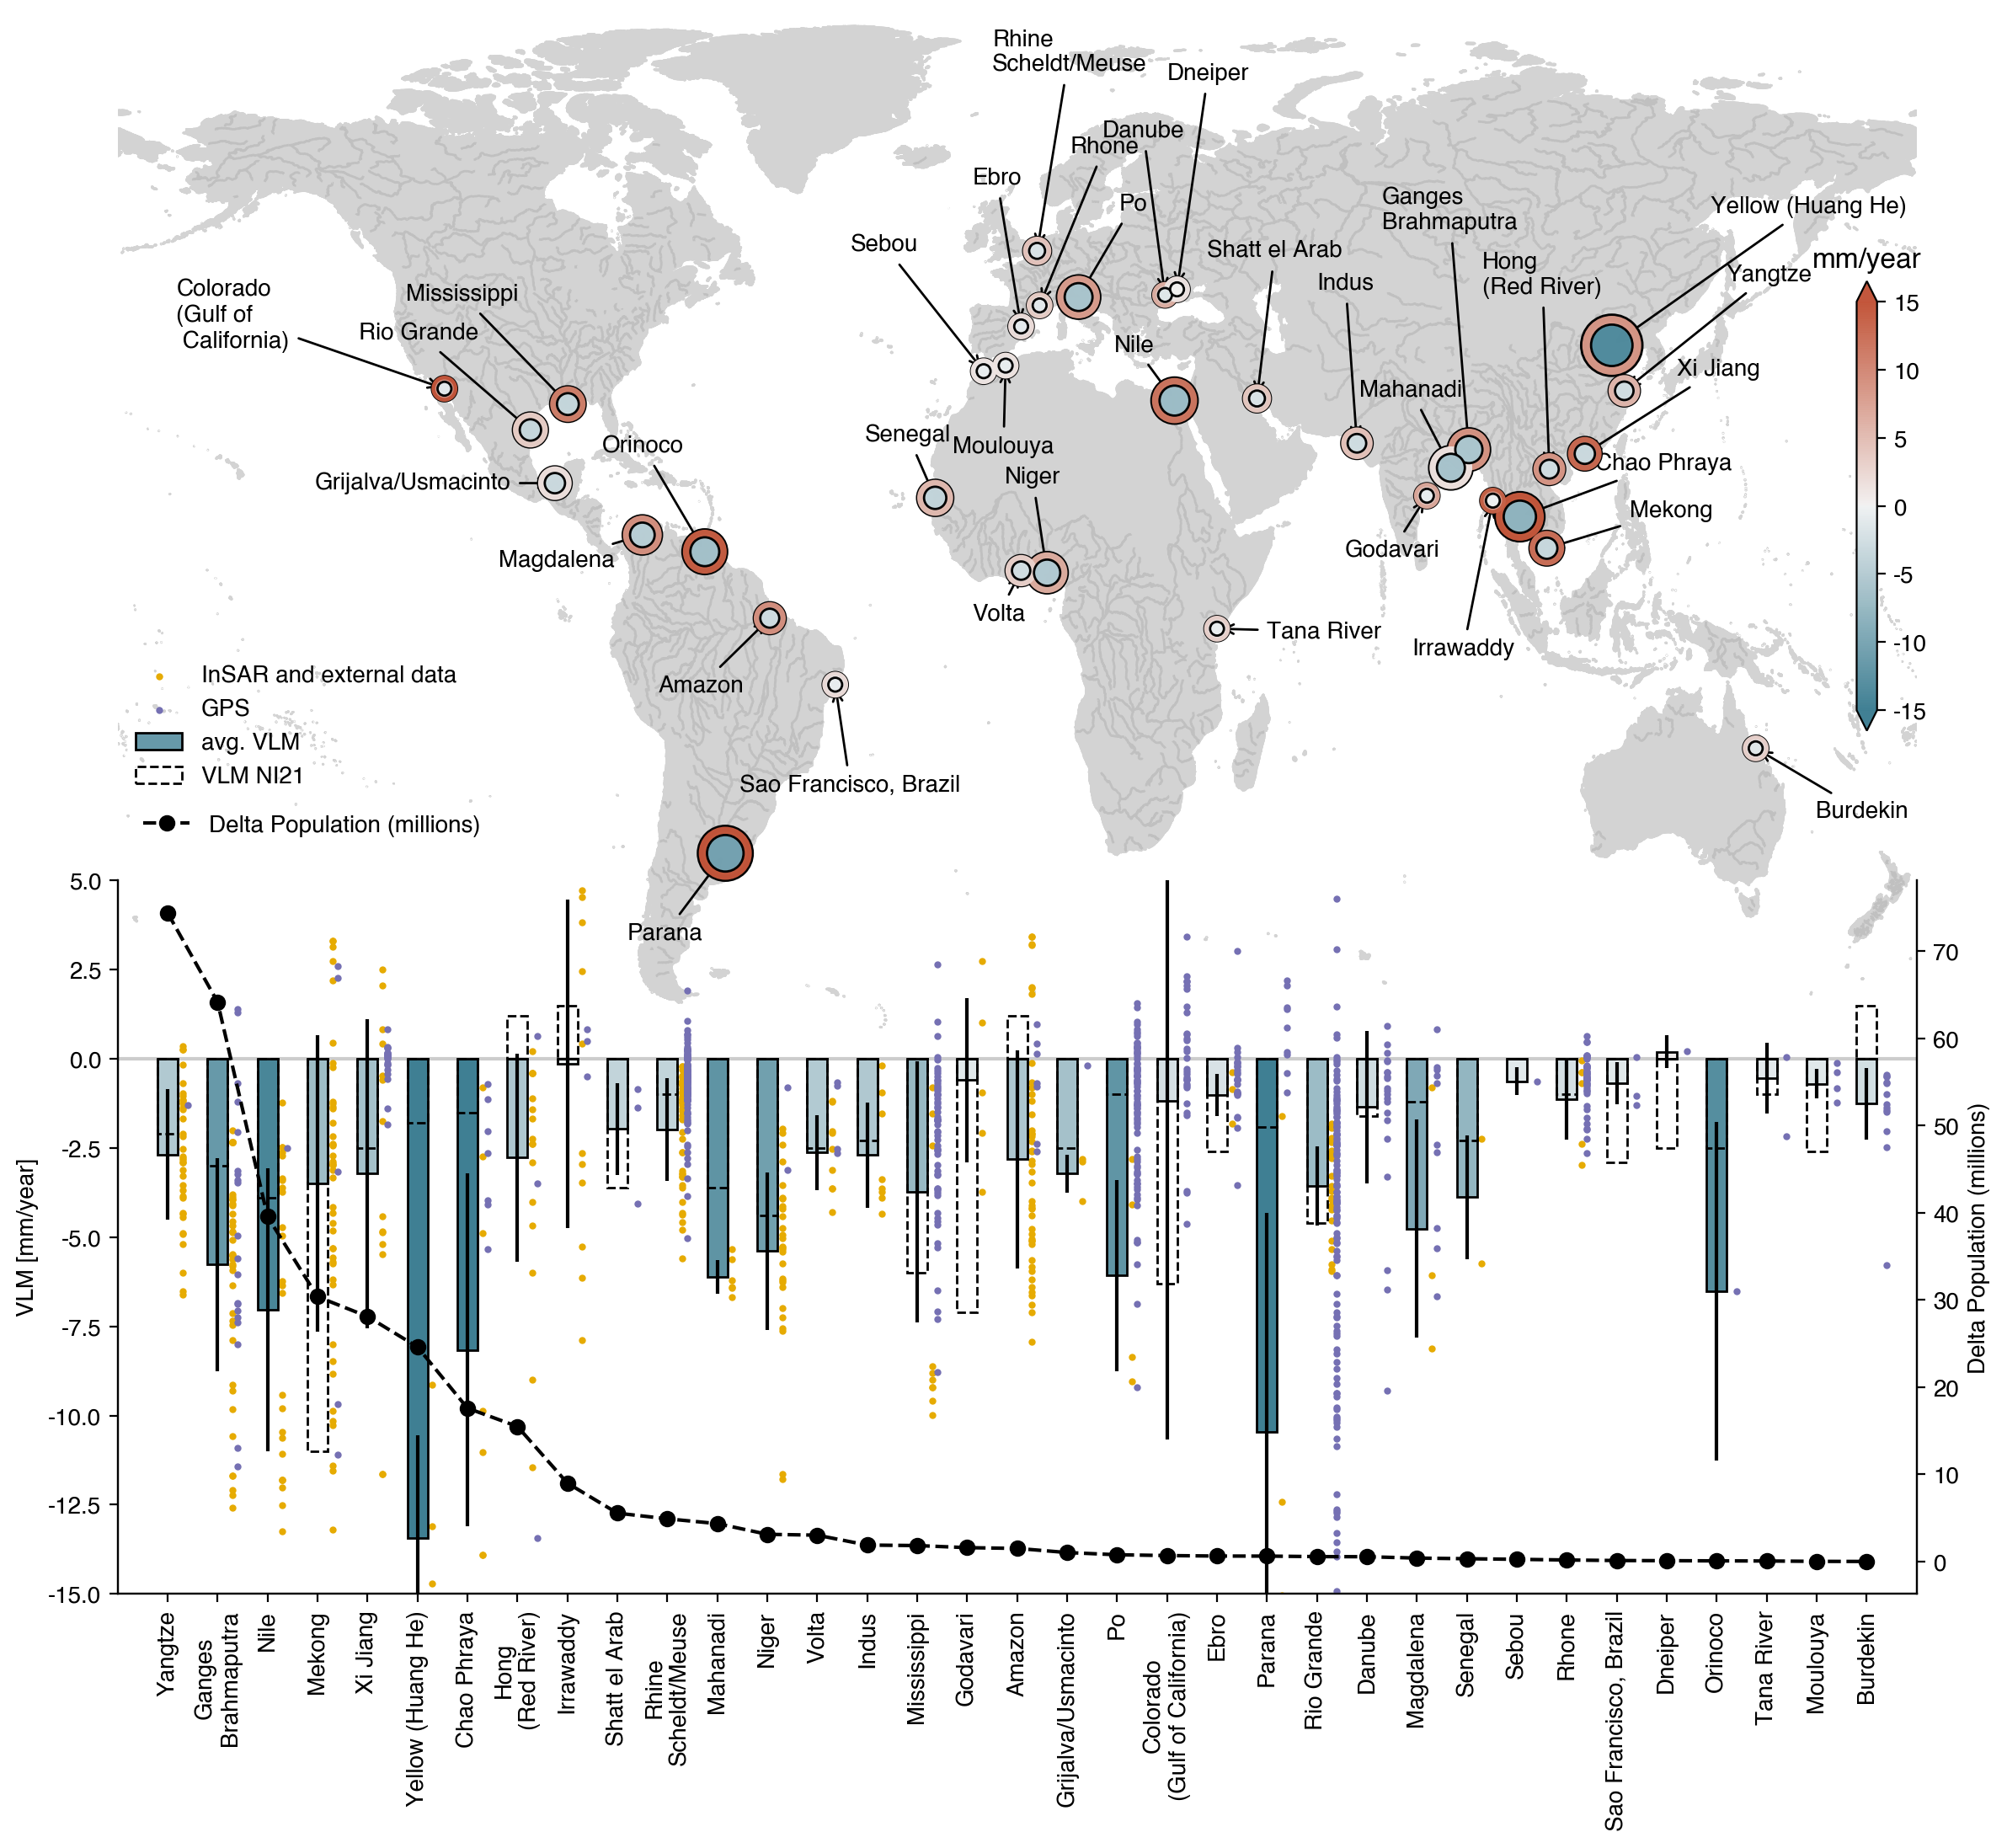

In [45]:
plt.rcParams.update({'font.sans-serif':'Helvetica'})

shifts_ =[[-30, 20], #ganges
 [-10, -8], #nile
 [0, 0],# yangtze
 [0, 0],# mekong
 [0, 0],# chao praya
 [0, 0],# peral
 [-30, -30],# irrawady
 [-30, 15],# hong
 [-30, 0], #Mahanadi
 [0, 10], # niger
 [0, -10],# amaton
 [0, 0],# rio grande
 [0, 0],# rhine
 [0, -10], # magdalena
 [-27, -17],# god
 [0, 0],# miss
 [-15, -10], #gr
 [0, 0],# ye
 #[-25, -25],# krish
 [5, 5],# paran
 [-12, 5],# shatt
 [-15, 10],# indus
 [0, -10],# Volta
 [-15, -10],# col
 [0, 0],# senegal

 [-10, 0],#da
 [-15, 0],#se
  [5,10],  # orinoco      
 [15, 0], #rhone
 [0, -30], #m
  [15,-10],          # po
 [0, -10], #sao
 [0, 7],#dn
 [0, 0],#ebr
 [-15, 0],#burd
 [10, 0],# tana 
 [0, 0]]# yukon


global proj

proj = ccrs.PlateCarree()

main_fontsize = 16
labelsize=12
plt.rc('axes', unicode_minus=False)
max_width =12

fig = plt.figure(figsize=(max_width,max_width*(1.1)),constrained_layout=True)
factor=3
number_of_plots = 4
xp = 1
yp=1
gs = gridspec.GridSpec(16*factor, 12*factor,wspace=0.0, hspace=0.0,top = 0.97, bottom = 0.2, right = 0.95, left = 0.06)



limits_ = [[-15,15]]

units = ['mm/year','mm/year','mm/year']
cbar_extends = ['both','both','both']

ii=0
jj=0


factorm=1
limits=limits_[0]
scaler_factor=1
scatter_kws={}

cmap_err = sns.diverging_palette(220, 20, as_cmap=True)
print(factorm)

variable = 'VLM_map_GIA'
size_map = 15

ax = fig.add_subplot(gs[int(ii*16/xp*factor):int((ii+0.75)*16/xp*factor),int(jj*12/yp*factor):int((jj+1)*12/yp*factor)],projection = proj)


size_map=60

ax,im = plot_map_ax_mapping(ax,ds_deltas['delta']+avg_use*factorm,region='custom',
                            msize=size_map,land_facecolor='lightgrey',aspect=1.4,edgecolor=['k'],
            scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.99,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3,zorder=5,scatter_kws={'linewidth':4}) 
size_map=50
ax,im = plot_map_ax_mapping(ax,ds_deltas['delta']+avg_use*factorm,region='custom',
                            msize=size_map,land_facecolor='lightgrey',aspect=1.4,edgecolor=[tuple(val) for val in cmap_err((ds_deltas['delta']+un_use)/10+0.5)],
            scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.99,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3,zorder=5,scatter_kws={'linewidth':4})

size_map=35

ax,im = plot_map_ax_mapping(ax,ds_deltas['delta']+avg_use*factorm,region='custom',
                            msize=size_map,land_facecolor='lightgrey',aspect=1.4,edgecolor=['k'],
            scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*abs(factorm),maxv = limits[1]*abs(factorm),alpha=0.99,alpha_overlay=.4,
                color_map=cmap_err,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,msize_frac=0.3,zorder=5,scatter_kws={'linewidth':1}) 


rivers_50m = cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '10m')
ax.add_feature(rivers_50m, facecolor='None', edgecolor='silver',zorder=0)  
texts = []



jj=0


for x in ds_deltas['delta'].x.values[:-1]:
    if ~np.isnan(avg_use)[x]:
        offset = jj
            
        lat_offset = ds_deltas.lat.values[x]/2+shifts_[jj][1]
        lon_offset = ds_deltas.lon.values[x]/4-10+shifts_[jj][0]
        

        name = data_c_sorted['Name Nicholls'].values[x]
        if name == 'Nile (East)':
            name ='Nile'
        if name == 'Xi Jiang (Pearl)':
            name ='Xi Jiang'    
        if name == 'Hong (Red River)':
            name ='Hong\n(Red River)'
        if name == 'Colorado (Gulf of California)':
            name ='Colorado\n(Gulf of\n California)'
        if name == 'Rhine/Scheldt/Meuse':
            name ='Rhine\nScheldt/Meuse'
        if name == 'Ganges/Brahmaputra':
            name ='Ganges\nBrahmaputra'
    
    
        ax.annotate(name,
            xy=[ds_deltas.lon.values[x],ds_deltas.lat.values[x]], xycoords='data',
            xytext=[ds_deltas.lon.values[x]+lon_offset,ds_deltas.lat.values[x]+lat_offset], textcoords='data',
            arrowprops=dict(arrowstyle="->", color="black", linewidth=1),fontsize=10)
        jj=jj+1

ax.axis('off')

ii=0
jj=0
inset_ax = fig.add_subplot(gs[int((ii+0.6)*16/xp*factor):,int(jj*12/yp*factor):int((jj+1)*12/yp*factor)])
inset_ax.set_facecolor("none")
jj=0
names= []
offsets=[]
indices_real = []

indices_realtrans = np.argsort(data_c_sorted['Pop_n'].values[~np.isnan(avg_use)])[::-1]

inset_ax.plot([-1,35],[0,0],color='grey',alpha=0.4)  
for x in ds_deltas['delta'].x.values:
    if ~np.isnan(avg_use)[x]:
        offset = jj
        # Plot the bar chart
        kwargs_b = {}
        kwargs_b2 = {}
        kwargs1 = {}
        kwargs2 = {}
        kwargs3 = {}
        
        if jj==0:
            kwargs1 = {'label':'CSL-TG'}
            kwargs2 = {'label':'InSAR and external data'}
            kwargs3 = {'label':'GPS'}
            kwargs_b = {'label':'avg. VLM'}
            kwargs_b2= {'label':'VLM NI21'}
        x_val = int(np.arange(len(indices_realtrans))[np.isin(indices_realtrans,jj)])
        
        print(x_val, avg_use[x],data_c_sorted['Name Nicholls'].values[x],jj)
        inset_ax.bar(x_val, avg_use[x], yerr=un_use[x],
                      color=cmap_err(avg_use[x]/limits[1]+0.5),edgecolor='k',width=0.4,**kwargs_b,zorder=40)
        
        inset_ax.bar(x_val, data_c_sorted['Subsidence (mm/yr)'].values[x],linestyle='dashed',
                     edgecolor='k',facecolor='none',width=0.4,**kwargs_b2,zorder=40)
        
        
        s=4            
  
        if len(InSAR_subsets[x])>0:
            inset_ax.scatter([x_val+0.1+0.2]*len(InSAR_subsets[x]),InSAR_subsets[x],color='#e6ab02',s=s,**kwargs2,zorder=40)
            
        if len(GPS_subsets[x])>0:
            inset_ax.scatter([x_val+0.1+0.3]*len(GPS_subsets[x]),GPS_subsets[x],color='#7570b3',s=s,**kwargs3,zorder=40)
        
        name = data_c_sorted['Name Nicholls'].values[x]
        if name == 'Nile (East)':
            name ='Nile'
        if name == 'Xi Jiang (Pearl)':
            name ='Xi Jiang'    
        if name == 'Hong (Red River)':
            name ='Hong\n(Red River)'
        if name == 'Colorado (Gulf of California)':
            name ='Colorado\n(Gulf of California)'
        if name == 'Rhine/Scheldt/Meuse':
            name ='Rhine\nScheldt/Meuse'
        if name == 'Ganges/Brahmaputra':
            name ='Ganges\nBrahmaputra'
            
        names.append(name) 
        offsets.append(jj)
        indices_real.append(x)
        jj=jj+1
        
inset_ax.set_ylim(-15,5)   
inset_ax.set_xlim(-1,jj)   
inset_ax.set_xticks(offsets)        
inset_ax.set_xticklabels(np.array(names)[indices_realtrans],rotation=90)

inset_ax.spines['top'].set_visible(False)
inset_ax.spines['top'].set_visible(False)
inset_ax.set_ylabel('VLM [mm/year]')
ax2 = inset_ax.twinx()  


ax2.plot(offsets, data_c_sorted['Pop_n'].values[~np.isnan(avg_use)][[x for x in indices_realtrans]]/1000000, color='k', 
         marker='o', linestyle='dashed', label="Delta Population (millions)")

ax2.set_ylabel("Delta Population (millions)", color='k')
ax2.spines['top'].set_visible(False)


ax2.legend(frameon=False, loc='lower right',bbox_to_anchor=(0.2132,1+0.032))
inset_ax.legend(frameon=False, loc='lower right',bbox_to_anchor=(0.05+0.15,1+0.1))


ax = fig.add_subplot(gs[int(0.15*16/xp*factor):int((0.6)*16/xp*factor),int(0.8*12/yp*factor):int((jj+1)*12/yp*factor)],projection = proj)
cbar_extend='both'
unit='mm/year'
clb =plt.colorbar(im,ax=ax, shrink=.6,extend=cbar_extend)
clb.ax.set_title(unit)
ax.set_rasterized('rasterized')

  
ax.axis('off')


plt.savefig(settings['plot_ext'] + 'SI5_Deltas_overview.png',bbox_inches='tight')
plt.savefig(settings['plot_ext'] + 'SI5_Deltas_overview.pdf',bbox_inches='tight')


plt.show()

